## Analysis: 

**Purpose**: Identify a suitable risk proxy for construction projects

### Question / Hypothesis

**Origin**: Based on the goal of identifying a suitable risk proxy for construction projects 

**Question**: What is the impact of each project and what are the features needed to determine project duration and potential for extension?

**Assumptions**:
- **Data**: Miami-Dade FDOT Work Program (post-ingestion: LOC_ERROR == "NO ERROR")
- **Fiscal years**: [e.g., 2024–2029 or subset]
- **Features under test**: [e.g., Shape__Length, WPPHAZGP, spatial density]
- **Other**: [Any filtering or subsetting]

### Data Loading

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

# Load data
_data_file = "data/processed/fdot_work_program_construction.gpkg"
candidates = [
    Path.cwd() / _data_file,
    Path.cwd().parent / _data_file,
]
# Get the first existing path
DATA_PATH = next((p for p in candidates if p.exists()), None)
# Error handling if path not found
if DATA_PATH is None:
    raise FileNotFoundError(
        f"Data not found. Tried: {candidates}. Run from project root or analysis/ and run ingest first."
    )

# Load data
gdf = gpd.read_file(DATA_PATH)
print(f"Shape: {gdf.shape}")
print(f"CRS: {gdf.crs}")
# Show first 5 rows
gdf.head()


Shape: (6820, 28)
CRS: EPSG:4326


,OBJECTID,WPITEM,WPITMSEG,ITMSEG,FINPROJ,RDWYLOC,BEGSECPT,ENDSECPT,RDWYSIDE,RDWYID,...,FISCALYR,PRPLCCDE,PRPLCODE,CONTYNAM,WPWKMIXN,WPITSTNM,LOCALFULL,LOC_ERROR,Shape__Length,geometry
0,36580,251156,3,2511563,25115635201,2,0.000,0.496,C,87059000,...,2029,A,03,MIAMI-DADE,NEW ROAD CONSTRUCTIO,CONST.COMPLETE,PORT OF MIAMI TUNNEL FROM PORT OF MIAMI TO SR ...,NO ERROR,797.883575,"LINESTRING (-80.17689 25.78677, -80.17653 25.7..."
1,36584,251688,1,2516881,25168815209,7,0.010,0.133,C,87200119,...,2026,A,01,MIAMI-DADE,BRIDGE-REPLACE AND A,UNDER CONSTRUCTION,SR 836/I-395 FROM WEST OF I-95 TO MACARTHUR CS...,NO ERROR,198.740872,"LINESTRING (-80.20079 25.7891, -80.20104 25.78..."
2,36585,251688,1,2516881,25168815204,5,0.000,0.102,C,87200123,...,2025,A,01,MIAMI-DADE,BRIDGE-REPLACE AND A,UNDER CONSTRUCTION,SR 836/I-395 FROM WEST OF I-95 TO MACARTHUR CS...,NO ERROR,170.858574,"LINESTRING (-80.19375 25.78592, -80.19314 25.7..."
3,36596,251688,1,2516881,25168815202,7,0.010,0.133,C,87200119,...,2024,A,01,MIAMI-DADE,BRIDGE-REPLACE AND A,UNDER CONSTRUCTION,SR 836/I-395 FROM WEST OF I-95 TO MACARTHUR CS...,NO ERROR,198.740872,"LINESTRING (-80.20079 25.7891, -80.20104 25.78..."
4,36597,251688,1,2516881,25168815201,11,12.455,12.655,R,87200000,...,2026,A,01,MIAMI-DADE,BRIDGE-REPLACE AND A,UNDER CONSTRUCTION,SR 836/I-395 FROM WEST OF I-95 TO MACARTHUR CS...,NO ERROR,319.343926,"LINESTRING (-80.19468 25.78619, -80.19435 25.7..."


## Data Filtering & Preparation

Apply any subsetting (e.g., fiscal year, phase type). Check schema, missingness, duplicates, geometry. See [Data Dictionary](../README.md#data-dictionary).

In [3]:
# Optional: subset by fiscal year or other filters
# df = gdf[gdf["FISCALYR"].between(2024, 2029)].copy()

# Schema & quality checks (adapt from eda.ipynb)
print("Columns:", gdf.columns.tolist())
print("Missingness:\n", gdf.isnull().sum()[gdf.isnull().sum() > 0])
print("Empty geometries:", gdf.geometry.is_empty.sum())

# Display first 5 rows CONTYDOT information
gdf[["WPWKMIXN", "WPITSTNM", "WPPHAZGP", "CONTYDOT", "CONTYNAM"]].head()
gdf[["PRPLCCDE", "PRPLCODE", "WPPHAZTP"]].head()

Columns: ['OBJECTID', 'WPITEM', 'WPITMSEG', 'ITMSEG', 'FINPROJ', 'RDWYLOC', 'BEGSECPT', 'ENDSECPT', 'RDWYSIDE', 'RDWYID', 'ITSEGMAN', 'WPWKMIX', 'WPITSTAT', 'MANDISDV', 'CONTYDOT', 'WPPHAZGP', 'WPPHAZTP', 'FINPRJSQ', 'FISCALYR', 'PRPLCCDE', 'PRPLCODE', 'CONTYNAM', 'WPWKMIXN', 'WPITSTNM', 'LOCALFULL', 'LOC_ERROR', 'Shape__Length', 'geometry']
Missingness:
 Series([], dtype: int64)
Empty geometries: 0


,PRPLCCDE,PRPLCODE,WPPHAZTP
0,A,03,2
1,A,01,2
2,A,01,2
3,A,01,2
4,A,01,2


In [10]:
status_counts = gdf.groupby(['WPITEM','WPITSTNM']).size().unstack(fill_value=0)
status_proportion = status_counts.div(status_counts.sum(axis=1), axis=0)
status_counts.head(20)

phase_type_counts = gdf.groupby(['WPPHAZTP']).size()
phase_type_counts

phase_type_name_type = gdf.groupby(['WPWKMIXN', 'WPPHAZTP']).size().unstack(fill_value=0)
# Display full name along with phase type
phase_type_name_type = gdf.groupby(['WPWKMIXN', 'WPPHAZTP']).size().unstack(fill_value=0)
phase_type_name_type = phase_type_name_type.reset_index()
phase_type_name_type = phase_type_name_type.merge(gdf[['WPWKMIXN', 'WPITSTNM']], on='WPWKMIXN', how='left')
phase_type_name_type



,WPWKMIXN,2,3,4,6,7,8,A,WPITSTNM
0,ADD AUXILIARY LANE(S,13,0,0,0,0,0,0,ROW ACQUISITION BEG.
1,ADD AUXILIARY LANE(S,13,0,0,0,0,0,0,ROW ACQUISITION BEG.
2,ADD AUXILIARY LANE(S,13,0,0,0,0,0,0,ROW ACQUISITION BEG.
3,ADD AUXILIARY LANE(S,13,0,0,0,0,0,0,ROW ACQUISITION BEG.
4,ADD AUXILIARY LANE(S,13,0,0,0,0,0,0,ROW ACQUISITION BEG.
...,...,...,...,...,...,...,...,...,...
6815,WIDEN/RESURFACE EXIS,0,0,6,0,0,2,0,"ADOPTED, NOT BEGUN"
6816,WIDEN/RESURFACE EXIS,0,0,6,0,0,2,0,CONTRACT EXECUTED
6817,WIDEN/RESURFACE EXIS,0,0,6,0,0,2,0,CONTRACT EXECUTED
6818,WIDEN/RESURFACE EXIS,0,0,6,0,0,2,0,"ADOPTED, NOT BEGUN"


## Calculations

Compute metrics for risk-proxy candidate features. Align with impact_score: `normalized_segment_length`, `phase_weight`, `spatial_density`.

In [3]:
# Segment length (for normalized_segment_length)
# Use Shape__Length (or Shape_Length) - units in source CRS
len_col = "Shape__Length" if "Shape__Length" in gdf.columns else "Shape_Length"
segment_length = gdf[len_col]  # e.g., gdf["Shape__Length"]

# Phase (for phase_weight): WPPHAZGP, WPPHAZTP, or WPITSTNM
phase_counts = gdf["WPPHAZGP"].value_counts() if "WPPHAZGP" in gdf.columns else None

# Spatial density: e.g., count of segments within buffer, or kernel density
# gdf["centroid"] = gdf.geometry.centroid
# density = ...  # implement based on hypothesis

# Your hypothesis-specific calculations here

## Test

Evaluate the hypothesis. EDA checklist (README): feature variance, non-pathological distributions, correlated structure, interpretability.

### Variance & distribution

Check variance (avoid near-zero), distribution shape (no single-feature dominance).

count     6820.000000
mean       653.212572
std       1102.883114
min          1.586149
25%        106.097193
50%        238.436300
75%        674.081817
max      11982.310208
Name: Shape__Length, dtype: float64
Variance: 1216351.1642067863
WPPHAZGP
5    6820
Name: count, dtype: int64


<Axes: >

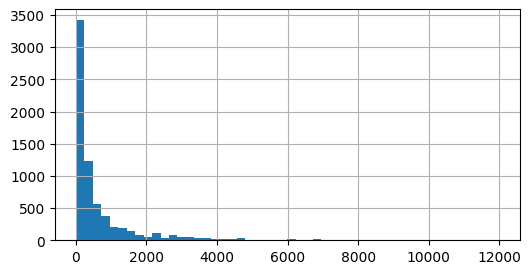

In [4]:
# Numeric feature variance (e.g., segment length)
print(segment_length.describe())
print("Variance:", segment_length.var())

# Categorical: value counts (e.g., phase)
if phase_counts is not None:
    print(phase_counts)

# Quick histogram
segment_length.hist(bins=50, figsize=(6, 3))

### Correlations (multicollinearity)

Flag strong correlations (|r| > 0.8) between candidate features.

In [5]:
# Numeric columns for correlation
numerics = gdf.select_dtypes(include=[np.number]).columns
if len(numerics) > 1:
    corr = gdf[numerics].corr()
    display(corr)
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > 0.8:
                print(f"Strong: {corr.columns[i]} vs {corr.columns[j]} = {r:.3f}")

,OBJECTID,RDWYLOC,BEGSECPT,ENDSECPT,FISCALYR,Shape__Length
OBJECTID,1.000000,-0.152394,-0.019889,-0.015738,0.276269,0.046418
RDWYLOC,-0.152394,1.000000,-0.078529,-0.094814,0.022626,-0.225555
BEGSECPT,-0.019889,-0.078529,1.000000,0.996981,0.004975,0.242500
ENDSECPT,-0.015738,-0.094814,0.996981,1.000000,0.001507,0.317094
FISCALYR,0.276269,0.022626,0.004975,0.001507,1.000000,-0.041963
Shape__Length,0.046418,-0.225555,0.242500,0.317094,-0.041963,1.000000


Strong: BEGSECPT vs ENDSECPT = 0.997


### Geospatial (optional)

Map sample, bounds, or density visualization.

Text(0.5, 1.0, 'Sample segments')

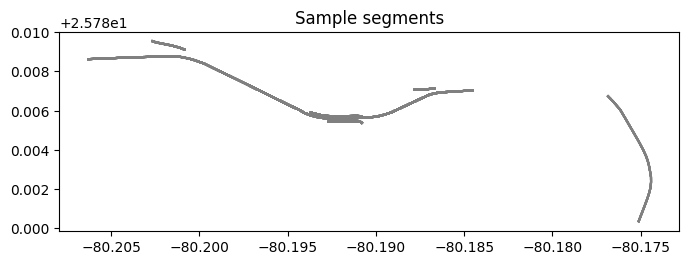

In [6]:
# Simple map (sample to keep small)
ax = gdf.head(500).plot(figsize=(8, 8), alpha=0.5, edgecolor="gray")
ax.set_title("Sample segments")


## Conclusion

Summarize findings and whether the feature(s) are viable for the risk-proxy model.

**Variance**: [Sufficient / near-zero / skewed?]

**Distribution**: [Non-pathological? Any single-feature dominance?]

**Correlations**: [Multicollinearity concerns?]

**Feature viability**: [Supported / not supported / inconclusive] for use in impact_score

## Next Steps

- [Follow-up hypothesis to test]
- [Additional feature(s) to evaluate]
- [Refinements to modeling pipeline]